# Prediksi Biaya Asuransi Kesehatan — Exploratory Data Analysis (EDA)

Dataset ini berisi informasi tentang biaya asuransi kesehatan individu di Amerika Serikat.
Tujuan utama adalah memprediksi kolom `charges` (biaya asuransi) berdasarkan fitur-fitur seperti:
- `age`: Umur
- `sex`: Jenis kelamin
- `bmi`: Body Mass Index (Indeks massa tubuh)
- `children`: Jumlah tanggungan anak
- `smoker`: Status perokok (yes/no)
- `region`: Wilayah tempat tinggal

Notebook ini akan mengeksplorasi data secara visual untuk memahami pola dan distribusi.

## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('Data/insurance.csv')
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## 2. Informasi Umum Dataset

In [2]:
print(f'Jumlah Baris : {df.shape[0]}')
print(f'Jumlah Kolom : {df.shape[1]}')
print()
df.info()

Jumlah Baris : 1338
Jumlah Kolom : 7

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
print('Missing Values per Kolom:')
print(df.isnull().sum())
print(f'\nTotal Missing Values: {df.isnull().sum().sum()}')
print(f'Jumlah Duplikat     : {df.duplicated().sum()}')

Missing Values per Kolom:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total Missing Values: 0
Jumlah Duplikat     : 1


## 3. Distribusi Target (Charges)

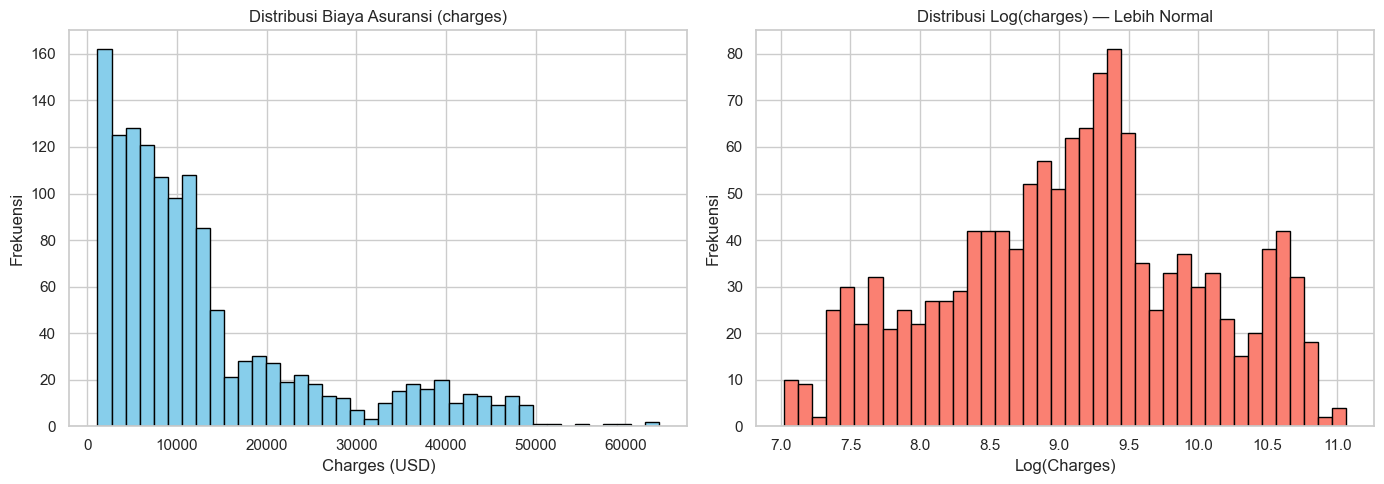

Skewness charges      : 1.52 (Positif = Condong Kanan)
Skewness log(charges)  : -0.09 (Mendekati 0 = Lebih Normal)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['charges'], bins=40, color='skyblue', edgecolor='black')
axes[0].set_title('Distribusi Biaya Asuransi (charges)')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(np.log1p(df['charges']), bins=40, color='salmon', edgecolor='black')
axes[1].set_title('Distribusi Log(charges) — Lebih Normal')
axes[1].set_xlabel('Log(Charges)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(f'Skewness charges      : {df["charges"].skew():.2f} (Positif = Condong Kanan)')
print(f'Skewness log(charges)  : {np.log1p(df["charges"]).skew():.2f} (Mendekati 0 = Lebih Normal)')

## 4. Distribusi Fitur Numerik

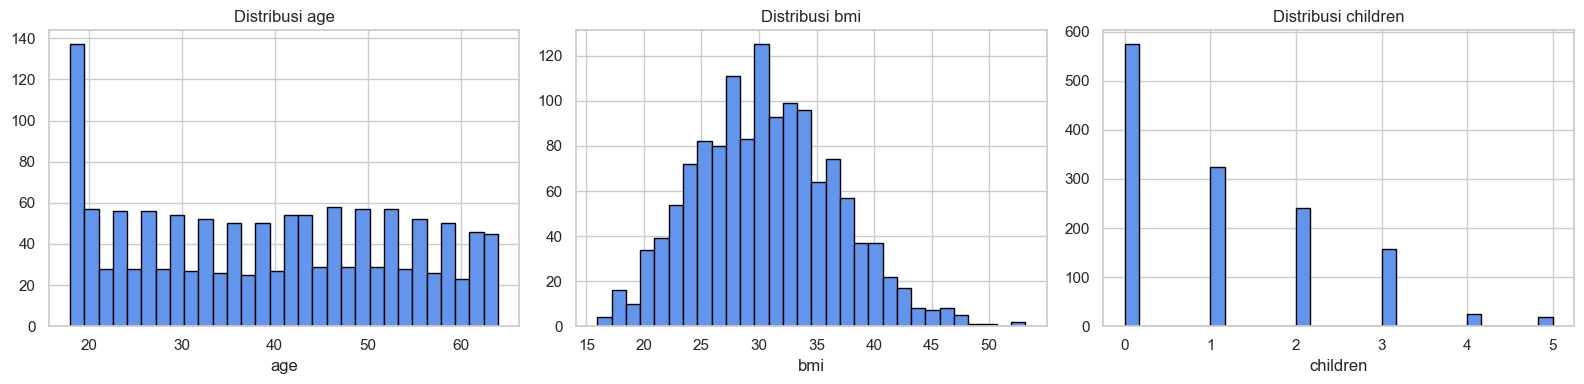

In [6]:
num_cols = ['age', 'bmi', 'children']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='cornflowerblue', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

## 5. Distribusi Fitur Kategorikal

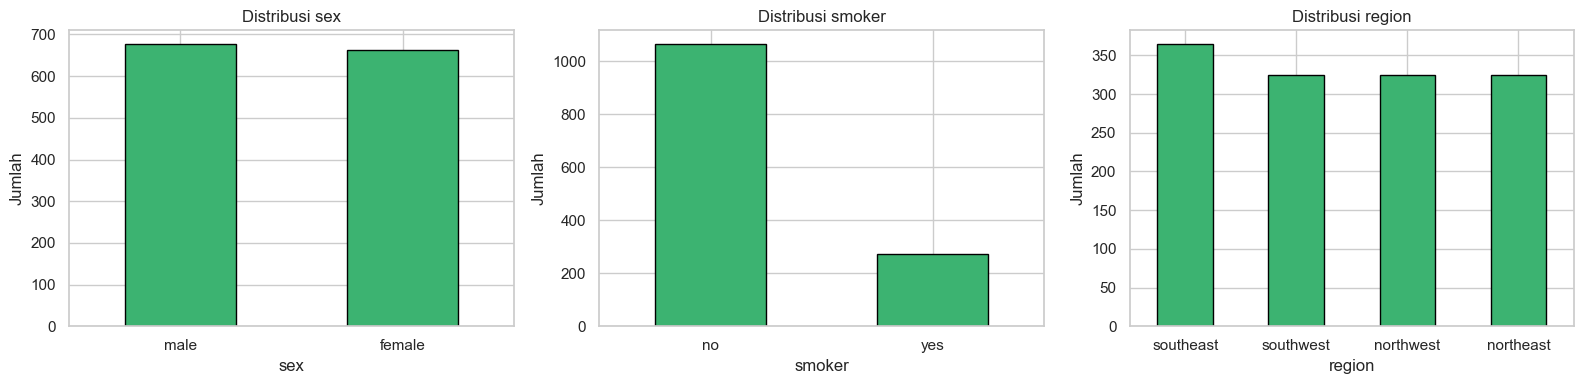

In [7]:
cat_cols = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='mediumseagreen', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. Hubungan Fitur dengan Biaya Asuransi

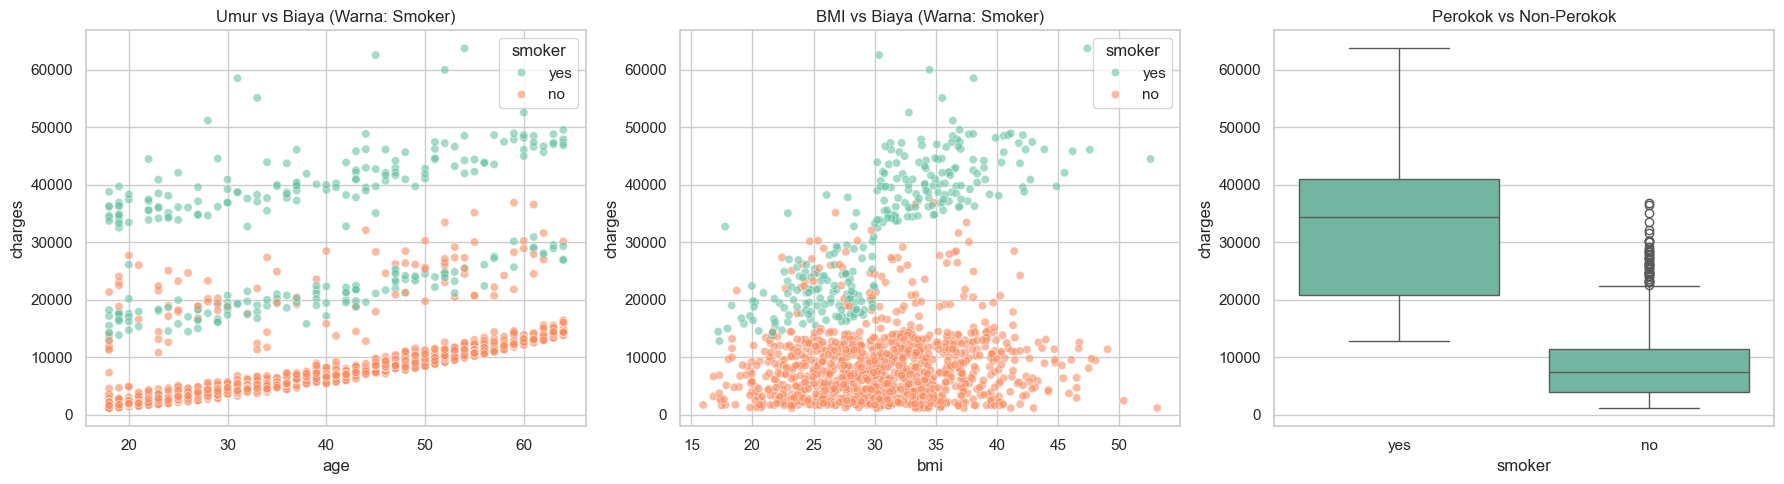

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x='age', y='charges', hue='smoker', ax=axes[0], alpha=0.6)
axes[0].set_title('Umur vs Biaya (Warna: Smoker)')

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', ax=axes[1], alpha=0.6)
axes[1].set_title('BMI vs Biaya (Warna: Smoker)')

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[2])
axes[2].set_title('Perokok vs Non-Perokok')

plt.tight_layout()
plt.show()

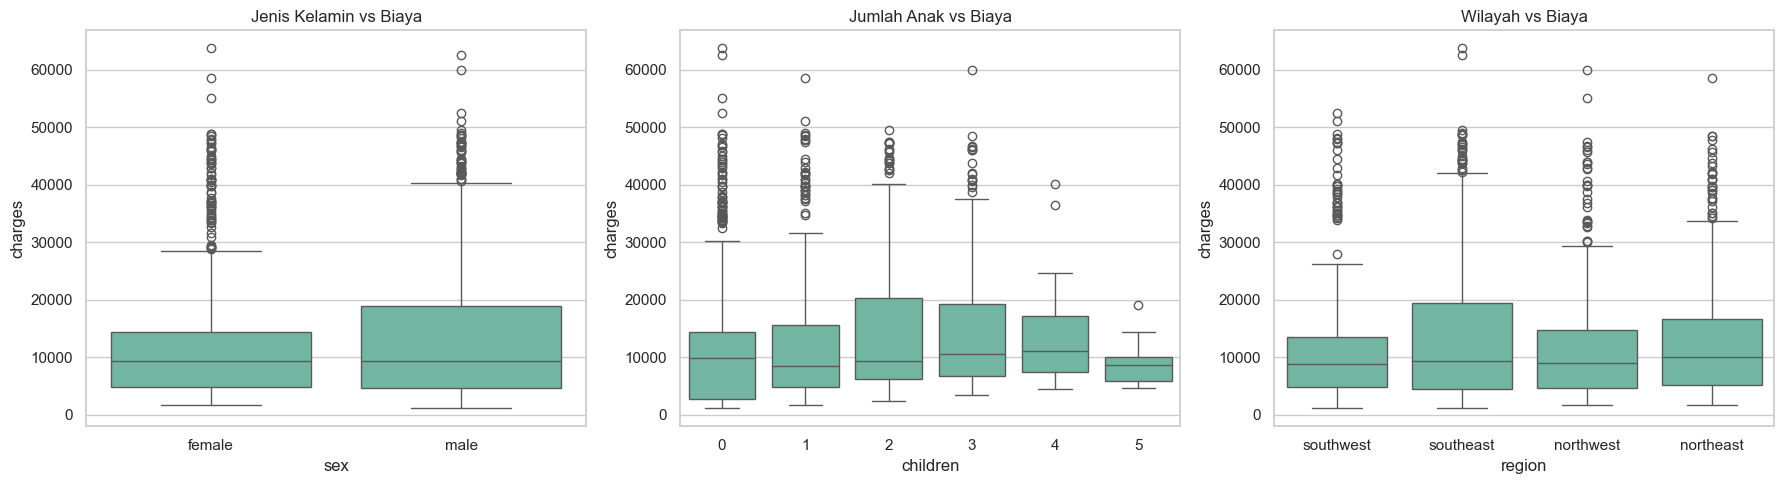

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='sex', y='charges', ax=axes[0])
axes[0].set_title('Jenis Kelamin vs Biaya')

sns.boxplot(data=df, x='children', y='charges', ax=axes[1])
axes[1].set_title('Jumlah Anak vs Biaya')

sns.boxplot(data=df, x='region', y='charges', ax=axes[2])
axes[2].set_title('Wilayah vs Biaya')

plt.tight_layout()
plt.show()

## 7. Korelasi antar Fitur Numerik

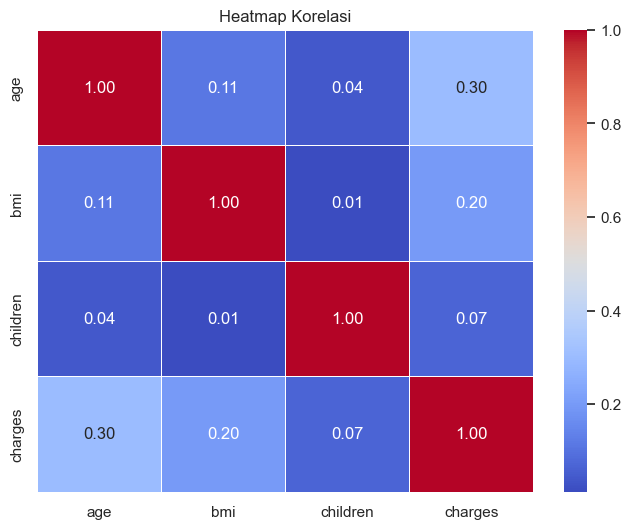

In [10]:
plt.figure(figsize=(8, 6))
corr = df[['age', 'bmi', 'children', 'charges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

## 8. Kesimpulan EDA

1. **Tidak ada missing values** dan hanya sedikit duplikat.
2. Distribusi `charges` **condong kanan (right-skewed)**, transformasi log bisa membantu model.
3. Faktor paling dominan yang mempengaruhi biaya asuransi adalah **status perokok (smoker)**.
4. **Umur** dan **BMI** juga berpengaruh, terutama untuk kelompok perokok.
5. Jenis kelamin dan wilayah tidak memiliki pengaruh yang signifikan.

Selanjutnya: Lakukan pembersihan data dan rekayasa fitur di **02_data_cleaning.ipynb**.